<!-- config-banner -->
# 04 — Member vs reference: magnitude vs structure metrics

**Question.** Quantitatively, how far is each ensemble member's adjoint
sensitivity from the reference — split into **magnitude** change vs
**structure** change — per variable, per depth level, and per lead time?

**Reads** (everything from `cache/` under
`/scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/`; no raw
run output is touched):

- `member_metrics_time.nc` — member-vs-reference metrics at all 366 dump
  iterations, both weightings (built by `build_cache.py`),
- `level_metrics_final.nc` — the same metrics per depth level for the fully
  accumulated (lead 5 yr) snapshot,
- `run_table.csv` + `stable_runs.npy` — run health and the stable/blown
  classification.

**Writes** figures to `figures/04_member_vs_reference_metrics/` and summary
CSVs (the handoff to notebook 07) to `stats/`, both under the same scratch
analysis root. Nothing is written into the repository.

Run table and suite reading order: see `README.md` in this directory.
Analysis date: **2026-08-30**.


In [1]:
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import ensemble_common as ec

ec.setup_style()
NB_STEM = "04_member_vs_reference_metrics"
ec.STATS_ROOT.mkdir(parents=True, exist_ok=True)

# Blown-up members carry values up to ~1e44; arithmetic on them is deliberate
# (log-axis plots, clipping), so silence the overflow chatter to keep cell
# outputs readable.
warnings.filterwarnings("ignore", message="overflow")
np.seterr(over="ignore", invalid="ignore")

mm = ec.open_cache("member_metrics_time.nc")     # (member, var, time, weighting)
lm = ec.open_cache("level_metrics_final.nc")     # (member, var3d, k, weighting)
run_table = pd.read_csv(ec.CACHE_DIR / "run_table.csv").set_index("run")
stable_runs = [str(r) for r in np.load(ec.CACHE_DIR / "stable_runs.npy")]

STABLE = [m for m in ec.MEMBERS if m in stable_runs]       # members only
BLOWN = [m for m in ec.MEMBERS if m not in stable_runs]
assert STABLE == ["M2", "M3", "M6"] and BLOWN == ["M1", "M4", "M5", "M7"]

# The time axis is FORWARD-model iteration, so the fully accumulated
# sensitivity (lead 5 yr) is the FIRST entry, not the last.
assert int(mm.time[0]) == ec.NITER0
assert float(mm.lead_years[0]) == 5.0
fin = mm.isel(time=0)          # final snapshot = lead 5 yr

VAR3 = list(ec.ADJ_3D)         # 6 three-dimensional ADJ fields
VAR2 = list(ec.ADJ_2D)         # 5 surface-forcing ADJ fields

print("member_metrics_time.nc :", dict(mm.sizes))
print("level_metrics_final.nc :", dict(lm.sizes))
print("stable subset (from cache):", stable_runs,
      "-> stable members", STABLE, "| blown members", BLOWN)
print("final snapshot = time index 0 = iteration "
      f"{int(mm.time[0])} = lead {float(mm.lead_years[0]):.1f} yr")

member_metrics_time.nc : {'member': 7, 'var': 11, 'time': 366, 'weighting': 2}
level_metrics_final.nc : {'member': 7, 'var': 6, 'k': 36, 'weighting': 2}
stable subset (from cache): ['M2', 'REF', 'M3', 'M6'] -> stable members ['M2', 'M3', 'M6'] | blown members ['M1', 'M4', 'M5', 'M7']
final snapshot = time index 0 = iteration 3162240 = lead 5.0 yr


## 1. Method — what each metric measures

Every metric compares a member field $m$ against the reference field $r$ over
wet cells (hFac > 0), optionally with weights $w$ (cell **volume** for 3-D
fields, cell **area** for 2-D fields; `weighting="none"` sets $w=1$). All of
them were computed by `build_cache.py` — at every one of the 366 dump
iterations, and per depth level for the final snapshot — from the definitions
in `ensemble_common.py` (`METRIC_FUNCS`); this notebook only reads the cached
results, so the numbers here are bit-identical to what any other notebook of
the suite reads.

With $m' = m - \langle m \rangle_w$ (weighted-mean removed):

| metric | formula | measures |
| --- | --- | --- |
| centered pattern correlation | $\rho = \dfrac{\sum w\,m'r'}{\sqrt{\sum w\,m'^2\,\sum w\,r'^2}}$ | **structure only** — invariant under $m \to a\,m+b$, $a>0$ |
| uncentered correlation | same, without removing means | structure + mean offset (cosine similarity) |
| amplitude ratio | $A = \mathrm{RMS}_w(m)\,/\,\mathrm{RMS}_w(r)$ | **magnitude only** — blind to structure (two uncorrelated fields of equal RMS give $A=1$) |
| regression slope | $s = \sum w\,m r \,/\, \sum w\,r^2$ | magnitude *conditional on structure*: identically $s = \rho_u\,A$ (uncentered corr × amplitude ratio), so it collapses when the pattern decorrelates even if the RMS does not |
| sign agreement | fraction of wet cells with $\mathrm{sign}(m) = \mathrm{sign}(r)$ (exact zeros excluded) | structure, robust to outliers; **0.5 = chance** |
| centered NRMSE | $E = \mathrm{RMS}_w(m'-r')\,/\,\sigma_w(r)$ | combined structure + amplitude error (Taylor 2001): $E^2 = 1 + a^2 - 2a\rho$ with $a=\sigma_m/\sigma_r$ |

So **$\rho$ and sign agreement isolate structure**, **$A$ isolates
magnitude**, and slope/NRMSE mix the two in known ways. The notebook body uses
**volume weighting** (each m³ of ocean counts equally); Section 6 verifies
that no conclusion depends on that choice.

**Blown members.** Four adjoints blow up during the reverse sweep (notebook
03); metrics are evaluated over cells where *both* fields are finite — which
only matters for M4, whose final ADJtheta is non-finite on 37% of wet cells.
For a blown member the metric is a well-defined number describing amplified
noise, not physics: such values appear as **open markers** throughout and are
never interpreted.

In [2]:
print("Metric vocabulary (ensemble_common.METRIC_LABELS):")
for k_, v_ in ec.METRIC_LABELS.items():
    print(f"  {k_:16s} {v_}")
print("\nWeighting convention:", mm.attrs["weighting"])

tab = run_table[["kappa_factor", "fc", "rms_final_ADJtheta",
                 "finite_frac_final_ADJtheta"]].copy()
tab["stable"] = [r in stable_runs for r in tab.index]
print("\nRun classification (stable = final ADJtheta finite everywhere AND "
      "wet RMS within 10x of REF):")
print(tab.to_string(float_format=lambda v: f"{v:.4g}"))

Metric vocabulary (ensemble_common.METRIC_LABELS):
  corr             pattern correlation (centered)
  corr_uncentered  pattern correlation (uncentered)
  amp_ratio        amplitude ratio  RMS(member)/RMS(ref)
  slope            regression slope on reference
  sign_agree       sign-agreement fraction
  nrmse_c          centered NRMSE (structure error)

Weighting convention: none = every wet cell equal; volume = cell volume (area for 2-D fields)

Run classification (stable = final ADJtheta finite everywhere AND wet RMS within 10x of REF):
     kappa_factor     fc  rms_final_ADJtheta  finite_frac_final_ADJtheta  stable
run                                                                             
M1           0.25 0.2141           2.302e+04                           1   False
M2            0.5 0.2598           6.316e-05                           1    True
REF             1  0.331           4.627e-05                           1    True
M3              2 0.2649           3.563e-05       

## 2. The master-plan plot — final-snapshot metrics vs κ

The primary comparison field is the **fully accumulated sensitivity**: the
dump at iteration 3 162 240 = lead 5 yr. Because dump files are numbered by
*forward* iteration while the adjoint computes backwards, this is the **first**
entry of the cached time axis (asserted in the setup cell) — an easy off-by-end
trap.

For each of the seven members we plot the three headline metrics against
$\log_2$(κ factor), one line per variable, volume-weighted:

- **pattern correlation** (structure),
- **amplitude ratio** on a log axis (magnitude; blown members reach
  $10^8$–$10^{44}$, far off any useful scale — off-scale points are drawn as
  open triangles pinned at the clip level),
- **sign agreement** (structure; 0.5 = chance).

Filled circles = stable members (M2, M3, M6 — with M6 already known to be
degraded), open symbols = blown members (M1, M4, M5, M7), whose values are
noise. The dotted vertical line marks the reference (1×), against which every
member is compared. First the six 3-D fields, then the five 2-D
surface-forcing fields.

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/04_member_vs_reference_metrics/final_metrics_vs_kappa_3d.png


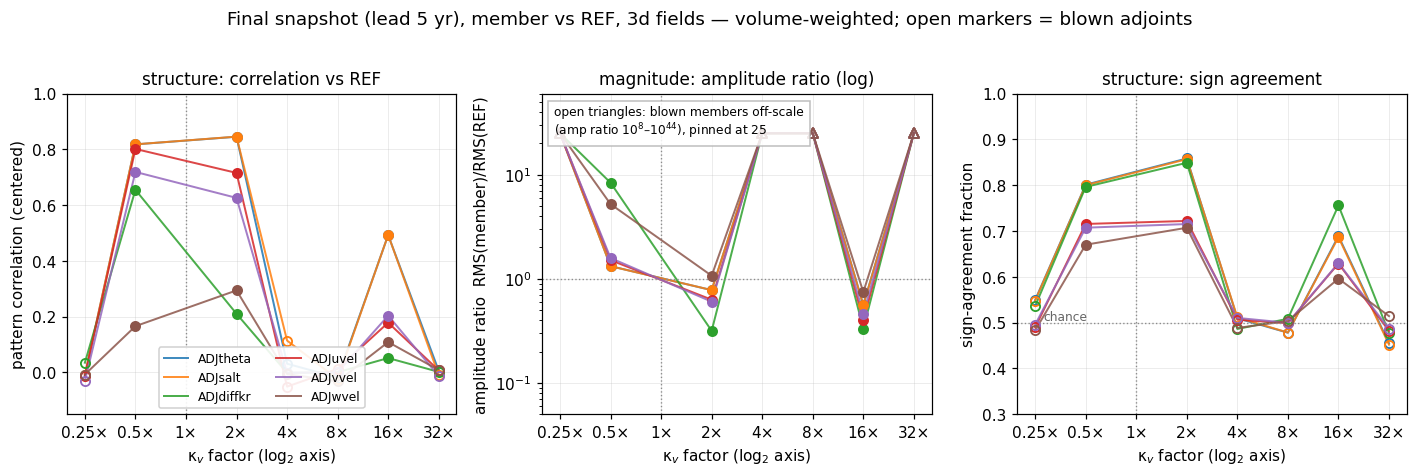

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/04_member_vs_reference_metrics/final_metrics_vs_kappa_2d.png


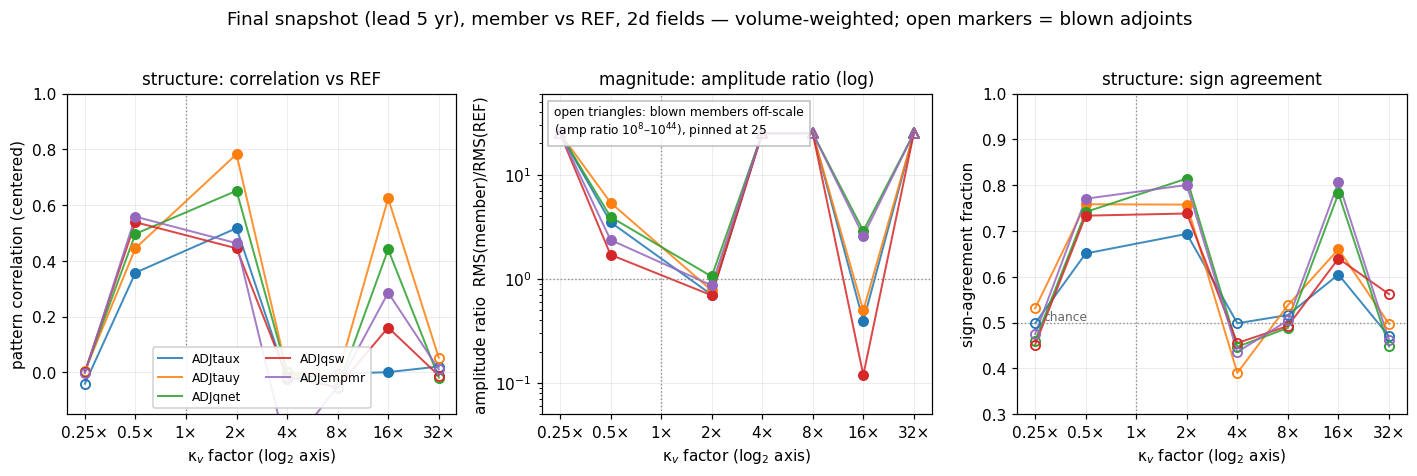


final-snapshot corr (volume-weighted), member x variable:
var     ADJtheta   ADJsalt  ADJdiffkr   ADJuvel   ADJvvel   ADJwvel   ADJtaux   ADJtauy   ADJqnet    ADJqsw  ADJempmr
member                                                                                                               
M1        -0.011    -0.009      0.035    -0.013    -0.031    -0.008    -0.041     0.004     0.002     0.002    -0.003
M2         0.818     0.818      0.655     0.802     0.719     0.166     0.358     0.446     0.497     0.539     0.559
M3         0.845     0.846      0.210     0.716     0.626     0.294     0.517     0.783     0.652     0.445     0.463
M4         0.031     0.114     -0.002    -0.051    -0.001    -0.006    -0.024     0.002     0.001    -0.016    -0.285
M5        -0.019    -0.024      0.001     0.013    -0.000    -0.032    -0.005    -0.015    -0.057    -0.053    -0.051
M6         0.493     0.493      0.051     0.178     0.204     0.109     0.001     0.624     0.441     0.161     0.2

In [3]:
X = np.array([np.log2(ec.RUNS[m]["factor"]) for m in ec.MEMBERS])
IS_BLOWN = np.array([m in BLOWN for m in ec.MEMBERS])
XT = np.log2([0.25, 0.5, 1, 2, 4, 8, 16, 32])
XTL = ["0.25×", "0.5×", "1×", "2×", "4×", "8×", "16×", "32×"]
AMP_CLIP = 25.0


def style_kappa_axis(ax):
    ax.set_xticks(XT)
    ax.set_xticklabels(XTL)
    ax.axvline(0.0, color="0.55", lw=0.9, ls=":", zorder=1)
    ax.set_xlabel("κ$_v$ factor (log$_2$ axis)")


def metric_panel(ax, metric, varlist, colors, clip=None):
    for v, c in zip(varlist, colors):
        y = fin[metric].sel(var=v, weighting="volume").values.astype(float)
        yp = np.minimum(y, clip) if clip else y
        ax.plot(X, yp, "-", color=c, lw=1.3, alpha=0.85, label=v, zorder=2)
        for xi, yi, blown, orig in zip(X, yp, IS_BLOWN, y):
            mk = "^" if (clip and orig > clip) else "o"
            ax.plot([xi], [yi], mk, ms=6, mec=c,
                    mfc="none" if blown else c, mew=1.2, zorder=3)
    style_kappa_axis(ax)


def master_plot(varlist, tag):
    colors = [plt.get_cmap("tab10")(i) for i in range(len(varlist))]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
    metric_panel(axes[0], "corr", varlist, colors)
    axes[0].set_ylim(-0.15, 1.0)
    axes[0].set_ylabel("pattern correlation (centered)")
    axes[0].set_title("structure: correlation vs REF")
    axes[0].legend(fontsize=8, ncol=2, loc="lower center")
    metric_panel(axes[1], "amp_ratio", varlist, colors, clip=AMP_CLIP)
    axes[1].set_yscale("log")
    axes[1].set_ylim(0.05, 60)
    axes[1].axhline(1.0, color="0.55", lw=0.9, ls=":")
    axes[1].set_ylabel("amplitude ratio  RMS(member)/RMS(REF)")
    axes[1].set_title("magnitude: amplitude ratio (log)")
    axes[1].text(0.03, 0.965, "open triangles: blown members off-scale\n"
                 "(amp ratio 10$^{8}$–10$^{44}$), pinned at 25",
                 transform=axes[1].transAxes, va="top", fontsize=8,
                 bbox=dict(fc="white", ec="0.7", alpha=0.85))
    metric_panel(axes[2], "sign_agree", varlist, colors)
    axes[2].set_ylim(0.3, 1.0)
    axes[2].axhline(0.5, color="0.55", lw=0.9, ls=":")
    axes[2].text(np.log2(0.28), 0.505, "chance", fontsize=8, color="0.4")
    axes[2].set_ylabel("sign-agreement fraction")
    axes[2].set_title("structure: sign agreement")
    fig.suptitle(f"Final snapshot (lead 5 yr), member vs REF, {tag} — "
                 "volume-weighted; open markers = blown adjoints", y=1.02)
    fig.tight_layout()
    ec.save_fig(fig, NB_STEM, f"final_metrics_vs_kappa_{tag.split()[0]}")
    plt.show()


master_plot(VAR3, "3d fields")
master_plot(VAR2, "2d fields")

for name, fmt in [("corr", "{:9.3f}"), ("amp_ratio", "{:9.3g}"),
                  ("sign_agree", "{:9.3f}")]:
    df = fin[name].sel(weighting="volume").to_pandas()[VAR3 + VAR2]
    print(f"\nfinal-snapshot {name} (volume-weighted), member x variable:")
    print(df.to_string(float_format=lambda v: fmt.format(v)))

### What the final-snapshot metrics say

- **Structure largely survives a factor-4 span of κ (0.5×–2×).** For the
  initial-state sensitivities ADJtheta/ADJsalt, M2 and M3 keep volume-weighted
  correlations of 0.82 and 0.85 with sign agreement 0.80 and 0.86. θ and S
  behave identically (corr 0.818 vs 0.818 for M2; 0.845 vs 0.846 for M3) — the
  temperature and salinity sensitivity patterns respond to κ together, as
  expected for density-driven adjoint dynamics.
- **Magnitude shifts by tens of percent, monotonically in κ.** ADJtheta
  amplitude ratios: 1.32 (M2, halving κ *raises* sensitivity amplitude), 0.78
  (M3), 0.56 (M6) — larger background diffusivity damps the accumulated
  sensitivity.
- **ADJdiffkr — the field a κ surrogate must predict — is far less robust
  than the state sensitivities**: corr 0.66 / 0.21 / 0.05 and amplitude ratio
  8.4 / 0.32 / 0.33 for M2 / M3 / M6. dJ/dκ changes strongly in *both*
  structure and magnitude when κ itself changes — a direct signature of the
  nonlinearity in κ that notebook 01 found in the ΔJ budget.
- **M6 (16×) is intermediate**, exactly as flagged in notebook 03: corr 0.49,
  sign 0.69, amplitude −44% for ADJtheta.
- **Blown members carry no signal at lead 5 yr**: |corr| ≤ 0.06, sign
  agreement 0.45–0.55 (chance), amplitude ratios $10^8$–$10^{44}$.
- **2-D surface-forcing sensitivities agree less well even for M2/M3**
  (corr 0.36–0.78; best ADJtauy for M3 at 0.78) — these fields carry more
  fast, small-scale structure than the accumulated interior state
  sensitivities.

## 3. Depth dependence — where in the vertical does agreement fail first?

`level_metrics_final.nc` holds the same metrics restricted to each of the 36
depth levels of the final snapshot. Per-level correlation is the sterner
test: the *global* volume-weighted correlation also gets credit for
reproducing the vertical amplitude envelope (cross-level covariance), which
per-level correlation strips away — so per-level values sit systematically
below the global ones of Section 2.

Profiles are shown for the stable members only (M2, M3, plus the degraded
M6) — blown members' final snapshots are noise at every level. Green dashed
line = bottom of the cost integral (k ≤ 25, 982 m): the region the cost
function J actually samples. ADJdiffkr is identically zero at the top level
(its uppermost interface is the sea surface, which carries no interior
diffusive flux), so its level-0 metrics are undefined — verified below.

cost-integral base: RF[25] = -982.4 m
ADJdiffkr k=0 metrics all NaN (field identically zero at the surface interface): True


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/04_member_vs_reference_metrics/level_profiles_stable_members.png


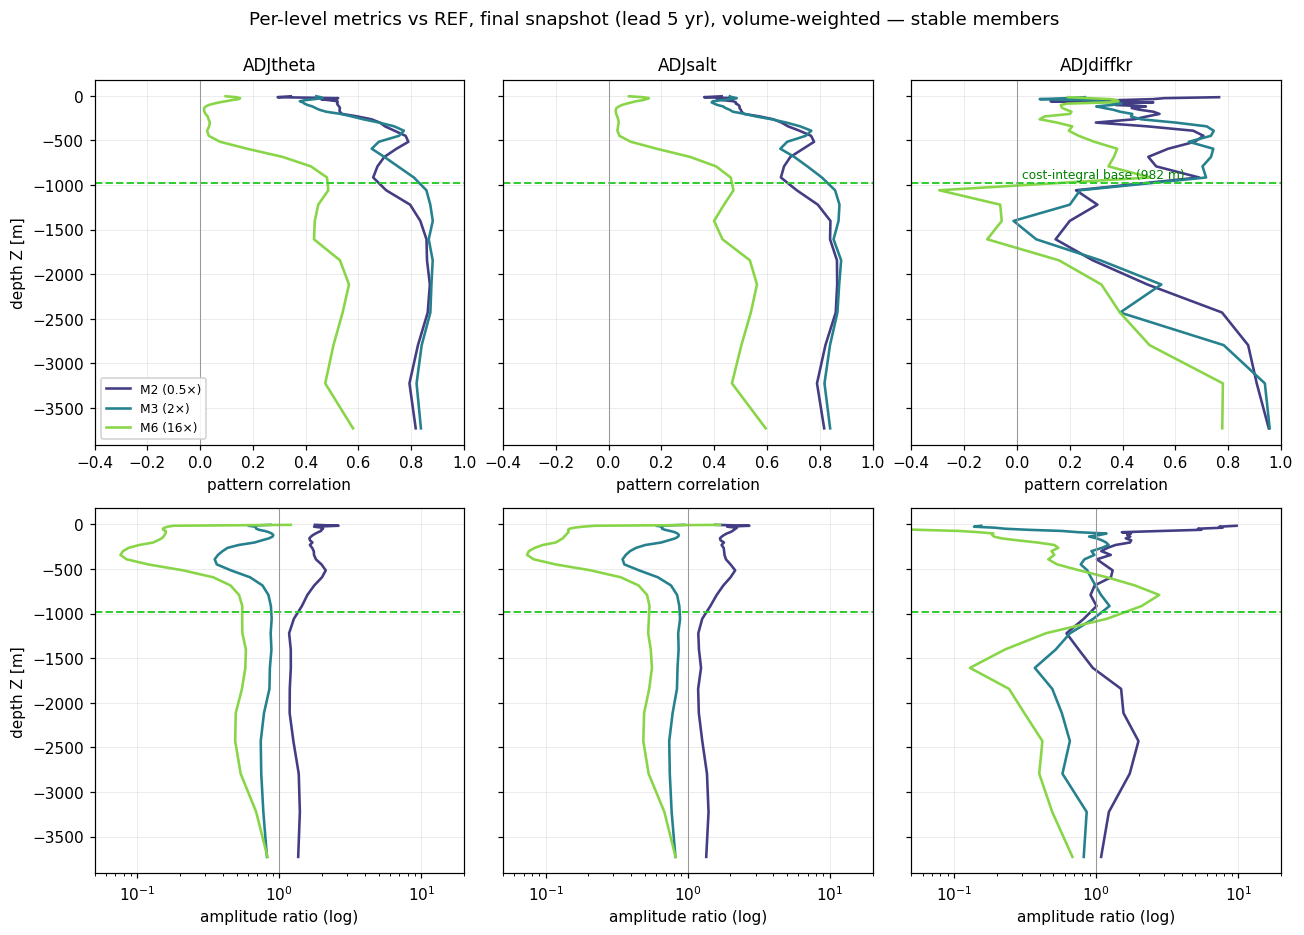


mean per-level correlation, cost-depth range (k<25) vs below:
                  mean_corr_upper982m  mean_corr_below
var       member                                      
ADJtheta  M2                    0.582            0.822
          M3                    0.552            0.860
          M6                    0.106            0.499
ADJsalt   M2                    0.564            0.821
          M3                    0.556            0.858
          M6                    0.110            0.494
ADJdiffkr M2                    0.506            0.517
          M3                    0.471            0.443
          M6                    0.254            0.240


In [4]:
g = ec.read_grid()
Z = lm.Z.values
zbot_cost = float(g["RF"][ec.KMAX])   # bottom of Fortran level 25 = -982.4 m
print(f"cost-integral base: RF[{ec.KMAX}] = {zbot_cost:.1f} m")

# ADJdiffkr top level is identically zero -> metrics undefined there
dk0 = lm["corr"].sel(var="ADJdiffkr", weighting="volume").isel(k=0).values
assert np.isnan(dk0).all()
print("ADJdiffkr k=0 metrics all NaN (field identically zero at the surface "
      "interface):", np.isnan(dk0).all())

VARP = ["ADJtheta", "ADJsalt", "ADJdiffkr"]
fig, axes = plt.subplots(2, 3, figsize=(12, 8.5), sharey=True)
for ci, v in enumerate(VARP):
    for row, metric in [(0, "corr"), (1, "amp_ratio")]:
        ax = axes[row, ci]
        for mem in STABLE:
            prof = lm[metric].sel(var=v, weighting="volume", member=mem).values
            ax.plot(prof, Z, color=ec.member_color(mem), lw=1.7,
                    label=ec.RUNS[mem]["label"])
        ax.axhline(zbot_cost, color="limegreen", lw=1.3, ls="--")
        if row == 0:
            ax.set_xlim(-0.4, 1.0)
            ax.axvline(0, color="0.6", lw=0.7)
            ax.set_title(v)
            ax.set_xlabel("pattern correlation")
        else:
            ax.set_xscale("log")
            ax.set_xlim(0.05, 20)
            ax.axvline(1, color="0.6", lw=0.7)
            ax.set_xlabel("amplitude ratio (log)")
axes[0, 0].set_ylabel("depth Z [m]")
axes[1, 0].set_ylabel("depth Z [m]")
axes[0, 0].legend(fontsize=8, loc="lower left")
axes[0, 2].text(0.02, zbot_cost + 60, "cost-integral base (982 m)",
                fontsize=8, color="green")
fig.suptitle("Per-level metrics vs REF, final snapshot (lead 5 yr), "
             "volume-weighted — stable members", y=0.995)
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "level_profiles_stable_members")
plt.show()

# aggregate: mean per-level corr inside vs below the cost-depth range
rows = []
for v in VARP:
    for mem in STABLE:
        prof = lm["corr"].sel(var=v, weighting="volume", member=mem).values
        rows.append(dict(var=v, member=mem,
                         mean_corr_upper982m=np.nanmean(prof[:ec.KMAX]),
                         mean_corr_below=np.nanmean(prof[ec.KMAX:])))
prof_tab = pd.DataFrame(rows).set_index(["var", "member"])
print("\nmean per-level correlation, cost-depth range (k<25) vs below:")
print(prof_tab.to_string(float_format=lambda x: f"{x:.3f}"))

### Reading the profiles

- **Agreement fails first near the surface and in the thermocline.** For
  M2/M3, per-level ADJtheta correlation is only ~0.3–0.5 above ~250 m, rises
  through the pycnocline, and reaches ≥ 0.8 below ~900 m. The deep ocean —
  slow, large-scale adjoint dynamics — is the most κ-robust part of the
  sensitivity field.
- **The cost-depth range is *not* privileged.** Mean per-level correlation in
  the k < 25 range (upper 982 m, the layer J integrates over) is *lower* than
  below it for every stable member and variable (printed table): structural
  robustness is set by the local dynamical regime, not by proximity to the
  cost integral in depth.
- **M6's degradation is concentrated in the thermocline**: ADJtheta/ADJsalt
  correlation ≈ 0 between roughly 70 and 450 m, recovering to only ~0.5 at
  depth. Its global corr of 0.49 is therefore a blend of a lost upper ocean
  and a half-preserved deep field — worth keeping in mind when using M6 at
  all (cf. notebook 03's "intermediate" verdict).
- **M2's amplitude excess is broadly distributed, not one anomalous layer**:
  per-level ADJtheta amplitude ratios run 1.6–2.6 through the upper 500 m
  (against 1.32 globally — the global value is pulled down by the
  better-matched deep levels).
- **ADJdiffkr is everywhere the weakest**: per-level correlations mostly
  0.2–0.7 even for M2/M3, with no depth range of high fidelity — consistent
  with Section 2's verdict that dJ/dκ itself depends strongly on κ.

## 4. Lead-time dependence — how long does structure survive?

The cached metrics exist at all 366 dumps, so correlation and amplitude ratio
can be followed as functions of **lead time** (years before the cost-window
end; the adjoint computes from lead 0 backwards to lead 5). Log-scaled lead
axis: the interesting transitions happen between weeks and a year.

Because the corr(lead) curves turn out to be **non-monotonic** (they dip and
partially recover), a plain "first crossing" scanning from long leads would
be ambiguous. The crossing statistic used here is the **sustained lead**:

> $L_{\rho \ge c}$ = the largest lead $L$ such that corr ≥ $c$ at *every*
> lead ≤ $L$ — i.e. how far back from the cost window the member tracks the
> reference without ever dropping below the threshold.

Computed for c = 0.9 and c = 0.5 on volume-weighted ADJtheta (the table
below; crossings also marked on the plot). A member that never drops below
the threshold within the window gets $L = \infty$ (reported as "> 5 yr").
The same crossing markers are drawn on the ADJdiffkr panel using its own
crossings.

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/stats/nb04_lead_crossings_ADJtheta_volume.csv

sustained-correlation leads, ADJtheta (volume-weighted); inf = never crossed within the 5-yr window:
        kappa_factor  stable  corr_lead_5d  L_corr090_yr  L_corr090_days  L_corr050_yr  corr_final_5yr
member                                                                                                
M1              0.25   False         0.982         0.109              40          2.53         -0.0111
M2               0.5    True         0.992         0.164              60           inf           0.818
M3                 2    True         0.996         0.191              70           inf           0.845
M4                 4   False         0.994         0.123              45         0.697          0.0311
M5                 8   False         0.992         0.109              40          1.26         -0.0186
M6                16    True         0.973         0.082 

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/04_member_vs_reference_metrics/metrics_vs_lead_time.png


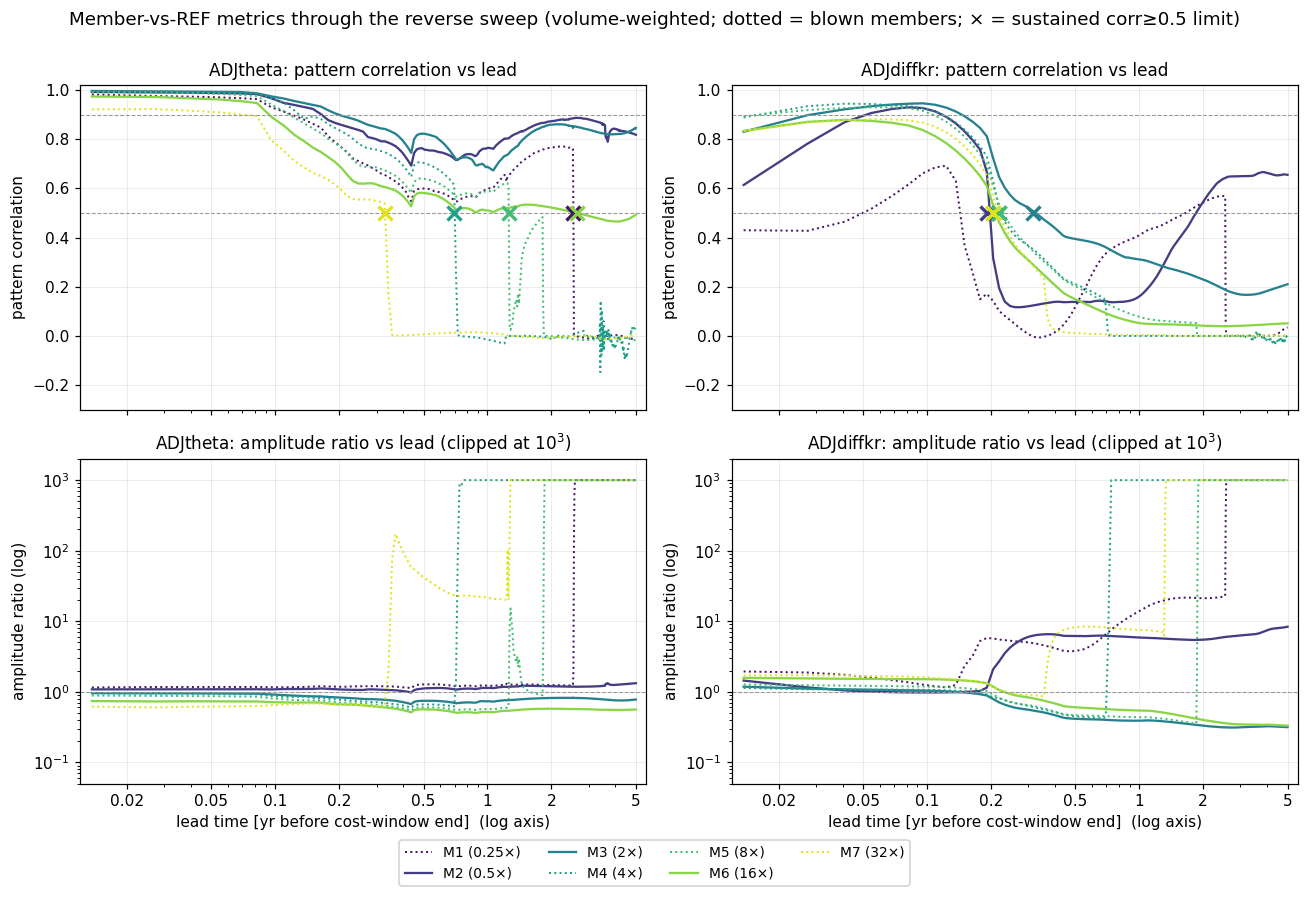

In [5]:
lead_all = mm.lead_years.values
order = np.argsort(lead_all)          # increasing lead
ls_ = lead_all[order]


def sustained_lead(cv, th):
    bad = np.where(cv < th)[0]
    if bad.size == 0:
        return np.inf
    return 0.0 if bad[0] == 0 else float(ls_[bad[0] - 1])


# ---- crossings table (ADJtheta, volume-weighted) --------------------------
cth = mm["corr"].sel(var="ADJtheta", weighting="volume")
rows = []
for mem in ec.MEMBERS:
    cv = cth.sel(member=mem).values[order]
    L09 = sustained_lead(cv, 0.9)
    L05 = sustained_lead(cv, 0.5)
    rows.append(dict(member=mem, kappa_factor=ec.RUNS[mem]["factor"],
                     stable=mem in STABLE,
                     corr_lead_5d=cv[0],
                     L_corr090_yr=L09, L_corr090_days=366.0 * L09,
                     L_corr050_yr=L05, corr_final_5yr=cv[-1]))
cross_df = pd.DataFrame(rows).set_index("member")
csvp = ec.STATS_ROOT / "nb04_lead_crossings_ADJtheta_volume.csv"
cross_df.to_csv(csvp)
print(f"saved {csvp}")
print("\nsustained-correlation leads, ADJtheta (volume-weighted); "
      "inf = never crossed within the 5-yr window:")
print(cross_df.to_string(float_format=lambda v: f"{v:.3g}"))

# dip diagnostics for the stable members
print("\nnon-monotonicity of corr(lead), stable members "
      "(minimum over leads 0.15-2 yr):")
for mem in STABLE:
    cv = cth.sel(member=mem).values[order]
    band = (ls_ >= 0.15) & (ls_ <= 2.0)
    i = int(np.argmin(np.where(band, cv, np.inf)))
    print(f"  {mem}: dip minimum corr {cv[i]:.3f} at lead {ls_[i]:.2f} yr; "
          f"final (5 yr) corr {cv[-1]:.3f}")

# ---- figure ----------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 7.6), sharex=True)
for ci, v in enumerate(["ADJtheta", "ADJdiffkr"]):
    axc, axa = axes[0, ci], axes[1, ci]
    for mem in ec.MEMBERS:
        kw = dict(color=ec.member_color(mem), lw=1.5,
                  label=ec.RUNS[mem]["label"])
        if mem in BLOWN:
            kw.update(ls=":", lw=1.3)
        cv = mm["corr"].sel(var=v, weighting="volume",
                            member=mem).values[order]
        axc.plot(ls_, cv, **kw)
        L05v = sustained_lead(cv, 0.5)
        if np.isfinite(L05v) and L05v > 0:
            axc.plot([L05v], [0.5], "x", color=ec.member_color(mem),
                     ms=9, mew=2.2, zorder=5)
        av = mm["amp_ratio"].sel(var=v, weighting="volume",
                                 member=mem).values[order]
        axa.plot(ls_, np.minimum(av, 1e3), **kw)
    for th in (0.9, 0.5):
        axc.axhline(th, color="0.6", lw=0.7, ls="--")
    axc.set_ylim(-0.3, 1.02)
    axc.set_title(f"{v}: pattern correlation vs lead")
    axc.set_ylabel("pattern correlation")
    axa.set_yscale("log")
    axa.set_ylim(0.05, 2e3)
    axa.axhline(1.0, color="0.6", lw=0.7, ls="--")
    axa.set_title(f"{v}: amplitude ratio vs lead (clipped at 10$^3$)")
    axa.set_ylabel("amplitude ratio (log)")
    axa.set_xlabel("lead time [yr before cost-window end]  (log axis)")
    axa.set_xscale("log")
    axa.set_xlim(0.012, 5.6)
    axa.set_xticks([0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5])
    axa.set_xticklabels(["0.02", "0.05", "0.1", "0.2", "0.5", "1", "2", "5"])
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc="lower center",
           bbox_to_anchor=(0.5, -0.055), fontsize=9)
fig.suptitle("Member-vs-REF metrics through the reverse sweep "
             "(volume-weighted; dotted = blown members; "
             "× = sustained corr≥0.5 limit)", y=1.0)
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "metrics_vs_lead_time")
plt.show()

### Reading the lead-time curves

- **Every member — blown ones included — tracks the reference at short
  leads**: sustained corr ≥ 0.9 for the first 25–70 days of lead (table
  above: M7 24.9 d … M3 69.9 d). That window matches the cost function's
  **terminal-30-day accumulation** (notebook 01's subtlety (a)): close to the
  cost window the adjoint field is dominated by the direct cost forcing,
  whose geometry is identical in every run; member-specific adjoint dynamics
  only take over beyond ~1 month of lead.
- **corr(lead) is not monotonic.** All stable members dip to ρ ≈ 0.67–0.69
  around leads 0.4–1.1 yr and then *recover* to ≥ 0.82 (M2, M3) by ~2 yr.
  Interpretation: at intermediate leads the fields are dominated by
  member-specific advective/mesoscale detail; the fully accumulated 5-yr
  field is smoother and large-scale, restoring the correlation. "Correlation
  decays with lead" is simply wrong for the stable members.
- **Blown members collapse abruptly and never recover.** Sustained
  corr ≥ 0.5 leads (ADJtheta): M7 0.33 yr, M4 0.70 yr, M5 1.26 yr, M1
  2.53 yr — non-monotonic in κ, in line with the blow-up ordering of
  notebooks 03/06 (the instability depends on each member's own background
  trajectory, not directly on κ). Before its collapse each blown member's
  structure is as good as a stable member's — **usable short-lead training
  windows exist for every member** (quantified per member in notebook 06 with
  a corr > 0.8 criterion).
- **M6 hovers at ρ ≈ 0.5 from ~1 yr of lead outward** (dip minimum 0.503,
  final 0.493). Its sustained-0.5 lead (2.64 yr) is fragile — the curve
  oscillates around the threshold rather than crossing it once; treat M6 as
  "half-degraded at all long leads", not as stable-until-2.6-yr.
- **ADJdiffkr loses structure much faster than ADJtheta** (right column):
  corr drops below 0.5 by lead ≈ 0.2–0.3 yr for every member. Unlike
  ADJtheta, dJ/dκ *accumulates* over the sweep (its RMS grows ~650× with
  lead, notebook 02), so its early-lead dumps are small and noisy; for
  M2/M3 the correlation partially recovers as accumulation smooths the
  field (to 0.66/0.21 at 5 yr).

## 5. Magnitude vs structure at a glance — the Taylor-like summary

One point per (stable member, variable) at the final snapshot: pattern
correlation on x (structure), amplitude ratio on log-y (magnitude). A
perfect clone sits at (1, 1). Points right and off-unity vertically =
"same map, different gain" — the benign case for a surrogate, since a scalar
amplitude correction fixes them. Points drifting left lose the map itself.
Circles = 3-D fields, squares = 2-D surface-forcing fields; colours by member
(viridis-graded in κ). The compact per-member table below it is the metric
hand-off to notebook 07.

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/04_member_vs_reference_metrics/amp_vs_corr_summary.png


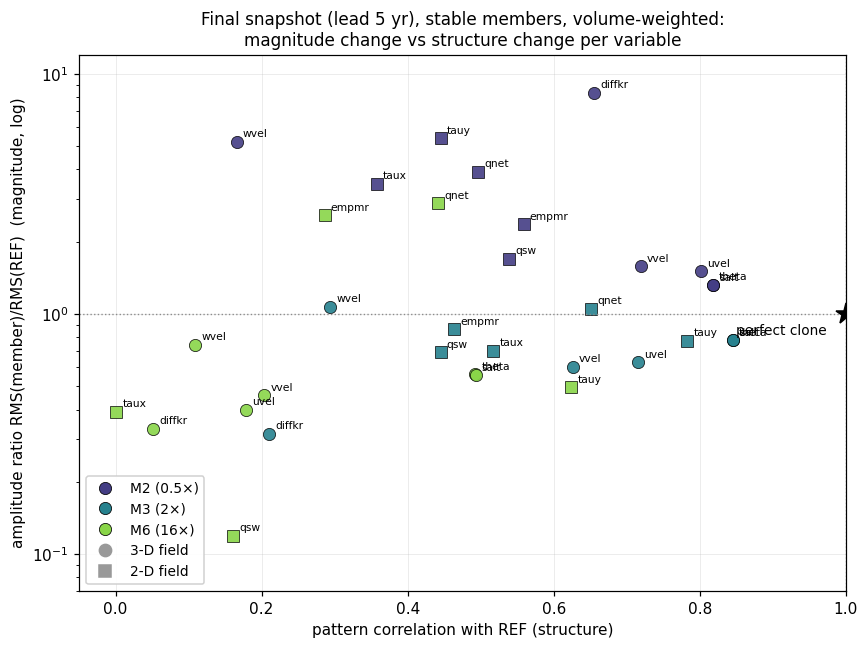

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/stats/nb04_stable_member_metrics_table.csv

Stable members, final snapshot, volume-weighted (ampchg% = (amplitude ratio - 1) x 100):
           corr_M2  ampchg%_M2  sign_M2  corr_M3  ampchg%_M3  sign_M3  corr_M6  ampchg%_M6  sign_M6
var                                                                                                
ADJtheta     0.818      32.310    0.801    0.845     -22.280    0.858    0.493     -43.868    0.689
ADJsalt      0.818      31.935    0.800    0.846     -22.159    0.857    0.493     -44.451    0.686
ADJdiffkr    0.655     736.471    0.796    0.210     -68.390    0.849    0.051     -66.798    0.756
ADJuvel      0.802      50.881    0.715    0.716     -37.048    0.722    0.178     -59.999    0.629
ADJvvel      0.719      58.126    0.707    0.626     -39.754    0.715    0.204     -54.119    0.630
ADJwvel      0.166     421.089    0.670    0.294       6.957    0.707    0.109     -25.462   


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/stats/nb04_final_metrics_lead5yr_volume.csv  (77 rows = 7 members x 11 variables)


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for mem in STABLE:
    for v in VAR3 + VAR2:
        x = float(fin["corr"].sel(var=v, weighting="volume", member=mem))
        y = float(fin["amp_ratio"].sel(var=v, weighting="volume", member=mem))
        ax.plot([x], [y], "o" if v in ec.ADJ_3D else "s",
                color=ec.member_color(mem), ms=8, mec="k", mew=0.5, alpha=0.9)
        ax.annotate(v.replace("ADJ", ""), (x, y), fontsize=7,
                    xytext=(4, 3), textcoords="offset points")
ax.set_yscale("log")
ax.set_ylim(0.07, 12)
ax.set_xlim(-0.05, 1.0)
ax.axhline(1.0, color="0.55", lw=0.9, ls=":")
ax.axvline(1.0, color="0.55", lw=0.9, ls=":")
ax.plot([1], [1], "k*", ms=14, zorder=5)
ax.annotate("perfect clone", (1, 1), xytext=(-72, -14),
            textcoords="offset points", fontsize=9)
from matplotlib.lines import Line2D
handles = ([Line2D([], [], marker="o", ls="", color=ec.member_color(m),
                   mec="k", mew=0.5, ms=8, label=ec.RUNS[m]["label"])
            for m in STABLE]
           + [Line2D([], [], marker="o", ls="", color="0.6", ms=8,
                     label="3-D field"),
              Line2D([], [], marker="s", ls="", color="0.6", ms=8,
                     label="2-D field")])
ax.legend(handles=handles, fontsize=9, loc="lower left")
ax.set_xlabel("pattern correlation with REF (structure)")
ax.set_ylabel("amplitude ratio RMS(member)/RMS(REF)  (magnitude, log)")
ax.set_title("Final snapshot (lead 5 yr), stable members, volume-weighted:\n"
             "magnitude change vs structure change per variable")
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "amp_vs_corr_summary")
plt.show()

# ---- compact stable-member table (the 07 hand-off) -------------------------
recs = []
for v in VAR3 + VAR2:
    row = dict(var=v)
    for mem in STABLE:
        sel = dict(var=v, weighting="volume", member=mem)
        row[f"corr_{mem}"] = float(fin["corr"].sel(**sel))
        row[f"ampchg%_{mem}"] = 100.0 * (float(fin["amp_ratio"].sel(**sel)) - 1.0)
        row[f"sign_{mem}"] = float(fin["sign_agree"].sel(**sel))
    recs.append(row)
stable_tab = pd.DataFrame(recs).set_index("var")
csvp = ec.STATS_ROOT / "nb04_stable_member_metrics_table.csv"
stable_tab.to_csv(csvp)
print(f"saved {csvp}")
print("\nStable members, final snapshot, volume-weighted "
      "(ampchg% = (amplitude ratio - 1) x 100):")
print(stable_tab.to_string(float_format=lambda v: f"{v:8.3f}"))

# ---- full hand-off: every member x variable x metric ----------------------
recs = []
for mem in ec.MEMBERS:
    for v in VAR3 + VAR2:
        sel = dict(var=v, weighting="volume", member=mem)
        recs.append(dict(member=mem, var=v,
                         kappa_factor=ec.RUNS[mem]["factor"],
                         stable=mem in STABLE,
                         **{met: float(fin[met].sel(**sel))
                            for met in ["corr", "corr_uncentered", "amp_ratio",
                                        "slope", "sign_agree", "nrmse_c"]}))
handoff = pd.DataFrame(recs)
csvp = ec.STATS_ROOT / "nb04_final_metrics_lead5yr_volume.csv"
handoff.to_csv(csvp, index=False)
print(f"\nsaved {csvp}  ({len(handoff)} rows = 7 members x 11 variables)")

### Per-member verdicts (stable subset, final snapshot)

- **M2 (0.5×)** — *same map, hotter*: structure preserved (ADJtheta ρ = 0.82,
  sign 0.80) with amplitude **up** ~30% for θ/S and up ×5–8 for
  ADJwvel/ADJdiffkr. A scalar (per-variable) gain correction recovers most of
  the reference field — except for ADJdiffkr, whose ×8.4 amplitude *and*
  ρ = 0.66 mean dJ/dκ genuinely changed.
- **M3 (2×)** — *the best structural twin*: highest correlations of the
  ensemble (θ 0.85, S 0.85, tauy 0.78), amplitude **down** ~22% for θ/S; but
  its dJ/dκ is nearly unrelated to the reference's (ρ 0.21, amplitude ×0.32).
- **M6 (16×)** — *half-lost*: ρ 0.49 / sign 0.69 / amplitude −44% for θ, with
  the loss concentrated in the thermocline (Section 3). Usable as a
  qualitative deep-pattern sample only.
- **Across variables**: θ and S metrics are pairwise near-identical;
  horizontal velocity sensitivities are slightly less robust (ADJuvel ρ
  0.80/0.72, ADJvvel 0.72/0.63 for M2/M3); ADJwvel is poor for everyone
  (ρ ≤ 0.29); the 2-D flux sensitivities sit in between. The robustness
  ordering (θ,S > u,v > 2-D fluxes > w, diffkr) is itself a useful surrogate
  design fact: the easiest targets to transfer across κ are the state
  sensitivities.

## 6. Does the weighting matter?

All conclusions above used volume weighting. The cache also carries the
unweighted variant (every wet cell equal). Since Section 3 showed agreement
improves with depth, and deep cells are the *thickest* (DRF grows from ~10 m
to ~250 m), volume weighting should *raise* correlations slightly. Check that
this shifts no conclusion: the comparison plot for ADJtheta, then the
difference table for all 3-D variables (stable members).

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/04_member_vs_reference_metrics/weighting_comparison_corr_ADJtheta.png


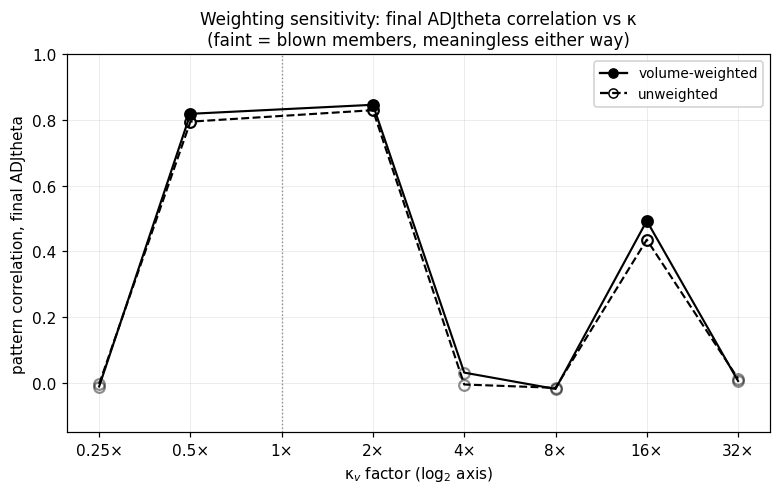

corr difference (volume - unweighted), stable members, 3-D variables:
var     ADJtheta  ADJsalt  ADJdiffkr  ADJuvel  ADJvvel  ADJwvel
member                                                         
M2        +0.024   +0.020     -0.009   +0.006   -0.008   -0.011
M3        +0.016   +0.010     -0.092   +0.057   +0.038   -0.007
M6        +0.057   +0.050     -0.001   +0.039   +0.044   -0.003

largest |difference|: 0.092 (variable ADJdiffkr)


member ranking by ADJtheta corr identical under both weightings: True


In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for wt, mfc, lab, lsty in [("volume", "k", "volume-weighted", "-"),
                           ("none", "none", "unweighted", "--")]:
    y = fin["corr"].sel(var="ADJtheta", weighting=wt).values
    ax.plot(X, y, lsty, color="k", lw=1.4)
    for xi, yi, blown in zip(X, y, IS_BLOWN):
        ax.plot([xi], [yi], "o" if not blown else "o", ms=7, mec="k",
                mfc=mfc if not blown else "none",
                mew=1.4, alpha=0.45 if blown else 1.0)
ax.plot([], [], "-o", color="k", label="volume-weighted")
ax.plot([], [], "--o", color="k", mfc="none", label="unweighted")
style_kappa_axis(ax)
ax.set_ylim(-0.15, 1.0)
ax.set_ylabel("pattern correlation, final ADJtheta")
ax.set_title("Weighting sensitivity: final ADJtheta correlation vs κ\n"
             "(faint = blown members, meaningless either way)")
ax.legend()
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "weighting_comparison_corr_ADJtheta")
plt.show()

dv = fin["corr"].sel(weighting="volume").to_pandas()[VAR3].loc[STABLE]
dn = fin["corr"].sel(weighting="none").to_pandas()[VAR3].loc[STABLE]
diff = dv - dn
print("corr difference (volume - unweighted), stable members, 3-D variables:")
print(diff.to_string(float_format=lambda v: f"{v:+.3f}"))
print(f"\nlargest |difference|: {np.abs(diff.values).max():.3f} "
      f"(variable {diff.abs().max().idxmax()})")
same_order = (dv["ADJtheta"].rank() == dn["ADJtheta"].rank()).all()
print("member ranking by ADJtheta corr identical under both weightings:",
      bool(same_order))

### Weighting verdict

Volume weighting raises the stable members' ADJtheta correlations by only
+0.02 to +0.06 (M6 largest, consistent with its relatively better deep field),
and the largest difference across all 3-D variables and stable members is
≈ 0.09 (ADJdiffkr, M3 — where the unweighted value is the *higher* one). The
member ranking is identical under both weightings, blown members are noise
under both, and no threshold crossing in this notebook moves. **The
conclusions do not depend on the weighting choice**; volume weighting is kept
as the default because it answers the physically posed question (each m³ of
ocean counted once).

## 7. Summary — the quantitative answer handed to notebook 07

**How different are the member sensitivities from the reference, where they
have physical meaning?**

- **Structure survives, magnitude shifts** across the stable κ range
  (0.5×–2×): final ADJtheta pattern correlation 0.82 (M2) / 0.85 (M3), sign
  agreement 0.80 / 0.86, amplitude ratios 1.32 / 0.78. M6 (16×) is
  half-degraded: ρ 0.49, amplitude 0.56. Blown members (M1, M4, M5, M7) are
  pure noise at lead 5 yr (|ρ| ≤ 0.06, sign ≈ chance, amplitude
  $10^8$–$10^{44}$).
- **ADJdiffkr — the κ-surrogate's target field — is the least transferable
  variable**: ρ 0.66 / 0.21 / 0.05 and amplitude ×8.4 / ×0.32 / ×0.33 for
  M2 / M3 / M6. Any surrogate mapping κ → dJ/dκ must represent strong
  structural change, not a gain factor.
- **Vertically**, agreement fails first above ~250 m and in the thermocline
  (M6: ρ ≈ 0 between ~70–450 m); the deep ocean (below ~900 m) is the most
  robust; the cost-depth range (k < 25) is *not* more robust than below it.
- **In lead time**, all nine adjoints agree (ρ ≥ 0.9) for only the first
  25–70 days — the footprint of the terminal-30-day cost forcing. Stable
  members then dip (ρ ≈ 0.67–0.69 near 0.4–1.1 yr) and *recover* to ≥ 0.82;
  blown members collapse abruptly at sustained-ρ≥0.5 leads of 0.33 (M7),
  0.70 (M4), 1.26 (M5) and 2.53 yr (M1) and never return — but are usable
  below those leads.
- **Weighting-independent**: volume vs unweighted changes correlations by
  ≤ 0.09 and no ranking or verdict.

**Hand-off files** (in `stats/` under the analysis root):
`nb04_final_metrics_lead5yr_volume.csv` (7 members × 11 variables × 6
metrics), `nb04_lead_crossings_ADJtheta_volume.csv` (sustained-correlation
leads), `nb04_stable_member_metrics_table.csv` (compact stable-member table).

**Caveats.** Metrics are computed over cells where both fields are finite —
only M4 is affected (37% of its final ADJtheta wet cells are non-finite).
There is a single reference realisation, so ρ carries no internal-variability
error bar (notebook 01 quantifies the noise floor on J, not on the fields).
M6's sustained-0.5 lead (2.64 yr) is fragile — its curve oscillates about
0.5. And the blown members' open-marker values are plotted for completeness
only; nothing quantitative should ever be read off them.